In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Run: pip install xgboost")

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
RECOVERY_RATE = 0.10
LGD = 1 - RECOVERY_RATE  
print(f"Recovery Rate: {RECOVERY_RATE:.0%} | Loss Given Default (LGD): {LGD:.0%}")

Recovery Rate: 10% | Loss Given Default (LGD): 90%


In [23]:

df = pd.read_csv("/Users/apple/Downloads/Task 3 and 4_Loan_Data.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape: 10,000 rows × 8 columns

Columns: ['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [24]:
print("Data Overview")
print(f"\nDefault Rate: {df['default'].mean():.2%}")
print(f"Non-Default:  {(1 - df['default'].mean()):.2%}")
print("\nMissing Values")
print(df.isnull().sum())
print("\nData Types")
print(df.dtypes)
print("\nData Statistics")
df.describe().round(2)
print(f"Raw Default Rate (before cleaning): {df['default'].mean():.2%}")
print(f"Raw Non-Default (before cleaning):  {(1 - df['default'].mean()):.2%}")
print(f"Raw Dataset Size: {len(df):,} rows")

Data Overview

Default Rate: 18.51%
Non-Default:  81.49%

Missing Values
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Data Types
customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object

Data Statistics
Raw Default Rate (before cleaning): 18.51%
Raw Non-Default (before cleaning):  81.49%
Raw Dataset Size: 10,000 rows


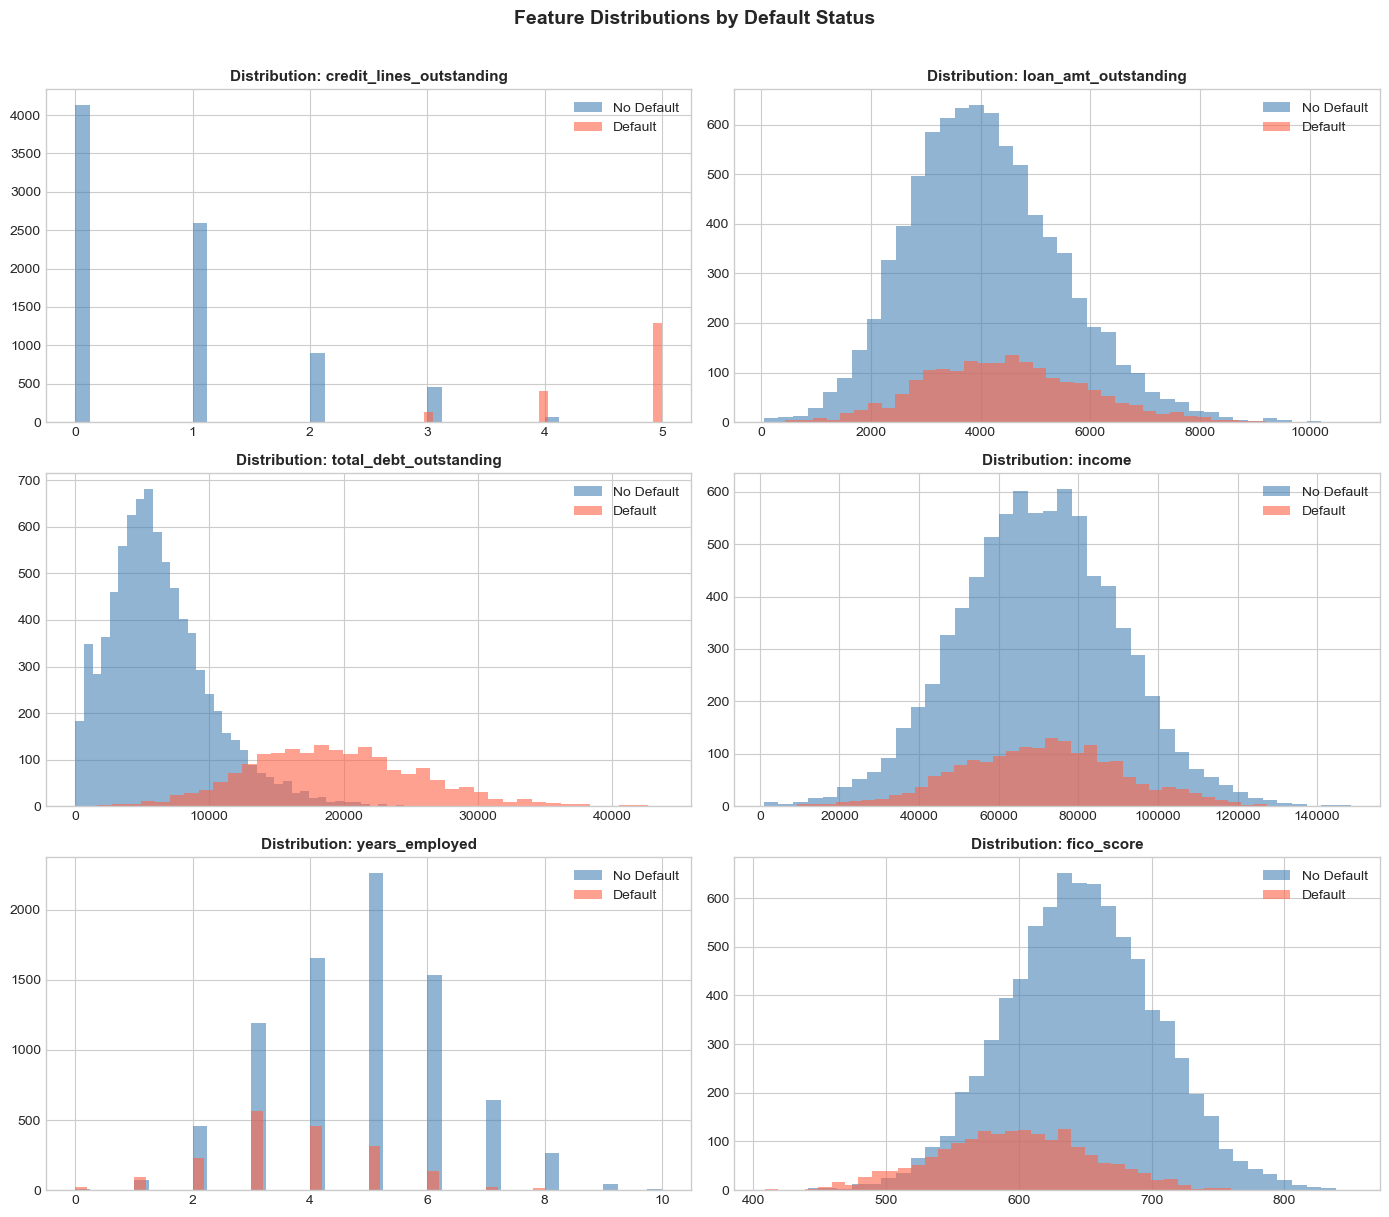

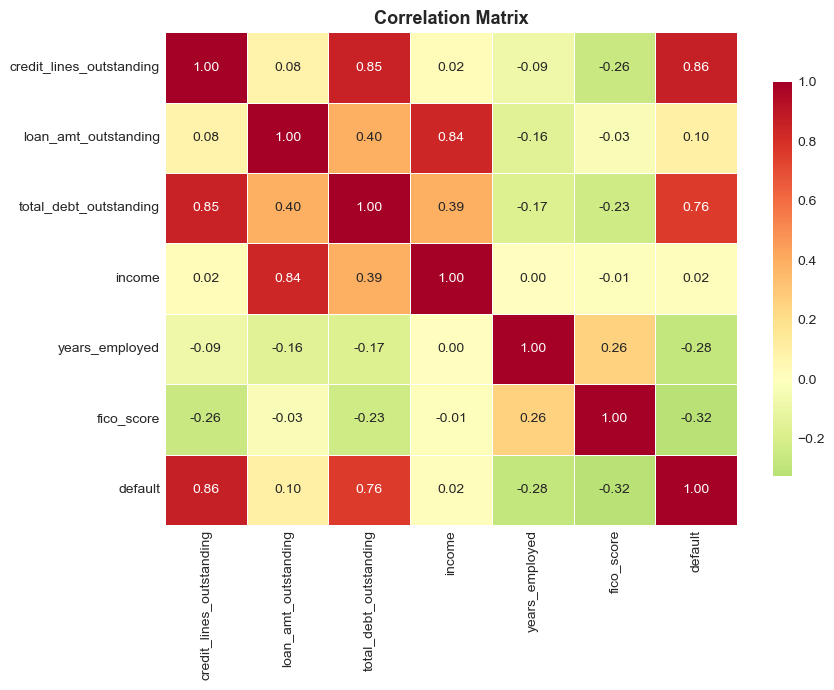

In [25]:
FEATURES = ['credit_lines_outstanding', 'loan_amt_outstanding',
            'total_debt_outstanding', 'income', 'years_employed', 'fico_score']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].hist(df[df['default'] == 0][col], bins=40, alpha=0.6, label='No Default', color='steelblue')
    axes[i].hist(df[df['default'] == 1][col], bins=40, alpha=0.6, label='Default', color='tomato')
    axes[i].set_title(f'Distribution: {col}', fontsize=11, fontweight='bold')
    axes[i].legend()

plt.suptitle('Feature Distributions by Default Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[FEATURES + ['default']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
df_clean = df.copy()
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df_clean)}")

for col in FEATURES:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        print(f"  Imputed missing in: {col}")

print(f"Negative income rows:        {(df_clean['income'] < 0).sum()}")
print(f"Negative loan amount rows:   {(df_clean['loan_amt_outstanding'] < 0).sum()}")
print(f"FICO out of [300,850] range: {((df_clean['fico_score'] < 300) | (df_clean['fico_score'] > 850)).sum()}")
print(f"Negative years_employed:     {(df_clean['years_employed'] < 0).sum()}")

df_clean = df_clean[
    (df_clean['income'] >= 0) &
    (df_clean['loan_amt_outstanding'] >= 0) &
    (df_clean['fico_score'].between(300, 850)) &
    (df_clean['years_employed'] >= 0)
]

WINSORISE_COLS = ['loan_amt_outstanding', 'total_debt_outstanding', 'income']
for col in WINSORISE_COLS:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR
    upper = Q3 + 3.0 * IQR
    clipped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"  {col}: clipped {clipped} values  [bounds: {lower:.0f}, {upper:.0f}]")

print(f"\nClean dataset: {df_clean.shape[0]:,} rows")
print(f"Default rate after cleaning: {df_clean['default'].mean():.2%}")

Duplicates removed: 0
Negative income rows:        0
Negative loan amount rows:   0
FICO out of [300,850] range: 0
Negative years_employed:     0
  loan_amt_outstanding: clipped 1 values  [bounds: -2542, 10749]
  total_debt_outstanding: clipped 51 values  [bounds: -17017, 32490]
  income: clipped 0 values  [bounds: -24128, 164097]

Clean dataset: 10,000 rows
Default rate after cleaning: 18.51%


In [27]:
df_feat = df_clean.copy()
df_feat['debt_to_income']       = df_feat['total_debt_outstanding'] / (df_feat['income'] + 1)
df_feat['loan_to_income']       = df_feat['loan_amt_outstanding']   / (df_feat['income'] + 1)
df_feat['loan_to_total_debt']   = df_feat['loan_amt_outstanding']   / (df_feat['total_debt_outstanding'] + 1)
df_feat['utilisation_rate']     = df_feat['total_debt_outstanding'] / (df_feat['income'] * 10 + 1) 
df_feat['fico_bucket']          = pd.cut(df_feat['fico_score'],
                                          bins=[300, 580, 670, 740, 800, 850],
                                          labels=[0, 1, 2, 3, 4]).astype(float)

ALL_FEATURES = FEATURES + [
    'debt_to_income', 'loan_to_income',
    'loan_to_total_debt', 'utilisation_rate', 'fico_bucket'
]

print("New features added:")
print("debt_to_income\n")
print("loan_to_income\n")
print("loan_to_total_debt\n")
print("utilisation_rate\n")
print("fico_bucket\n")

X = df_feat[ALL_FEATURES].copy()
y = df_feat['default'].copy()
print(f"\nFeature matrix shape: {X.shape}")

New features added:
debt_to_income

loan_to_income

loan_to_total_debt

utilisation_rate

fico_bucket


Feature matrix shape: (10000, 11)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test  default rate: {y_test.mean():.2%}")

Train size: 8,000  |  Test size: 2,000
Train default rate: 18.51%
Test  default rate: 18.50%


In [29]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=20,
                             class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test)

print("RANDOM FORREST CLASSIFIER")
print(classification_report(y_test, rf_pred, target_names=['No Default', 'Default']))
print(f"ROC-AUC:      {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Brier Score:  {brier_score_loss(y_test, rf_proba):.4f}")

fi = pd.DataFrame({'Feature': ALL_FEATURES, 'Importance': rf.feature_importances_})
fi = fi.sort_values('Importance', ascending=False)
print("\nFeature Importances:")
print(fi.to_string(index=False))

RANDOM FORREST CLASSIFIER
              precision    recall  f1-score   support

  No Default       1.00      0.98      0.99      1630
     Default       0.91      0.98      0.95       370

    accuracy                           0.98      2000
   macro avg       0.96      0.98      0.97      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC:      0.9987
Brier Score:  0.0139

Feature Importances:
                 Feature  Importance
        utilisation_rate    0.314574
          debt_to_income    0.270267
credit_lines_outstanding    0.159157
      loan_to_total_debt    0.142827
  total_debt_outstanding    0.084465
          years_employed    0.010954
              fico_score    0.007505
             fico_bucket    0.004361
          loan_to_income    0.002638
                  income    0.002186
    loan_amt_outstanding    0.001066


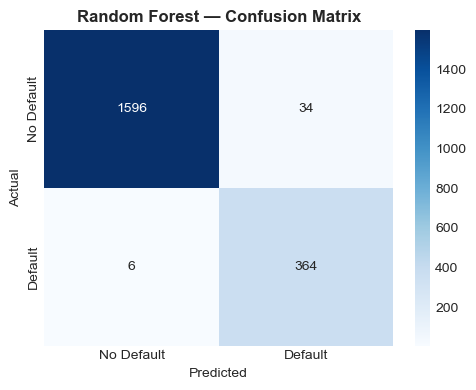

In [30]:
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

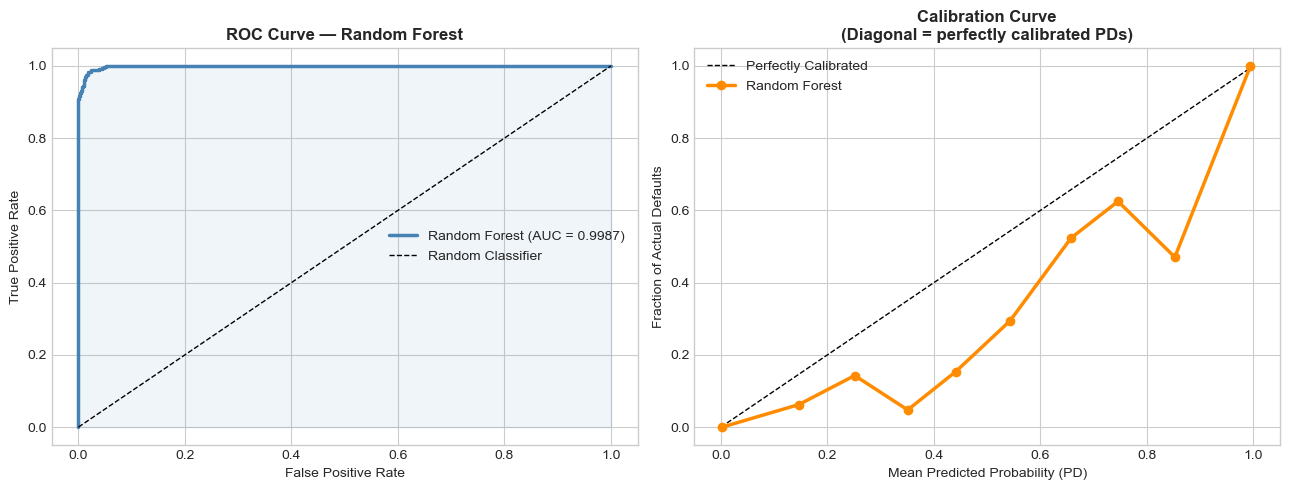

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, rf_proba)
auc = roc_auc_score(y_test, rf_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2.5, label=f'Random Forest (AUC = {auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='steelblue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Random Forest', fontweight='bold')
axes[0].legend()

fraction_pos, mean_pred = calibration_curve(y_test, rf_proba, n_bins=10)
axes[1].plot([0,1],[0,1],'k--', label='Perfectly Calibrated', lw=1)
axes[1].plot(mean_pred, fraction_pos, marker='o', color='darkorange',
             lw=2.5, label='Random Forest')
axes[1].set_xlabel('Mean Predicted Probability (PD)')
axes[1].set_ylabel('Fraction of Actual Defaults')
axes[1].set_title('Calibration Curve\n(Diagonal = perfectly calibrated PDs)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
fi_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Gini_Importance': rf.feature_importances_
}).sort_values('Gini_Importance', ascending=False).reset_index(drop=True)

print("Built-in (Gini) Feature Importance:")
print(fi_df.to_string(index=False))

Built-in (Gini) Feature Importance:
                 Feature  Gini_Importance
        utilisation_rate         0.314574
          debt_to_income         0.270267
credit_lines_outstanding         0.159157
      loan_to_total_debt         0.142827
  total_debt_outstanding         0.084465
          years_employed         0.010954
              fico_score         0.007505
             fico_bucket         0.004361
          loan_to_income         0.002638
                  income         0.002186
    loan_amt_outstanding         0.001066


In [33]:
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=15,
    random_state=RANDOM_STATE,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Permutation_Mean': perm.importances_mean,
    'Permutation_Std':  perm.importances_std
}).sort_values('Permutation_Mean', ascending=False).reset_index(drop=True)

print("Permutation Importance (ROC-AUC drop when feature is shuffled):")
print(perm_df.round(5).to_string(index=False))

Permutation Importance (ROC-AUC drop when feature is shuffled):
                 Feature  Permutation_Mean  Permutation_Std
        utilisation_rate           0.00675          0.00116
          debt_to_income           0.00540          0.00105
credit_lines_outstanding           0.00199          0.00058
          years_employed           0.00060          0.00008
              fico_score           0.00034          0.00005
             fico_bucket           0.00009          0.00002
          loan_to_income           0.00006          0.00002
      loan_to_total_debt           0.00004          0.00006
  total_debt_outstanding           0.00004          0.00002
                  income           0.00001          0.00001
    loan_amt_outstanding          -0.00000          0.00001


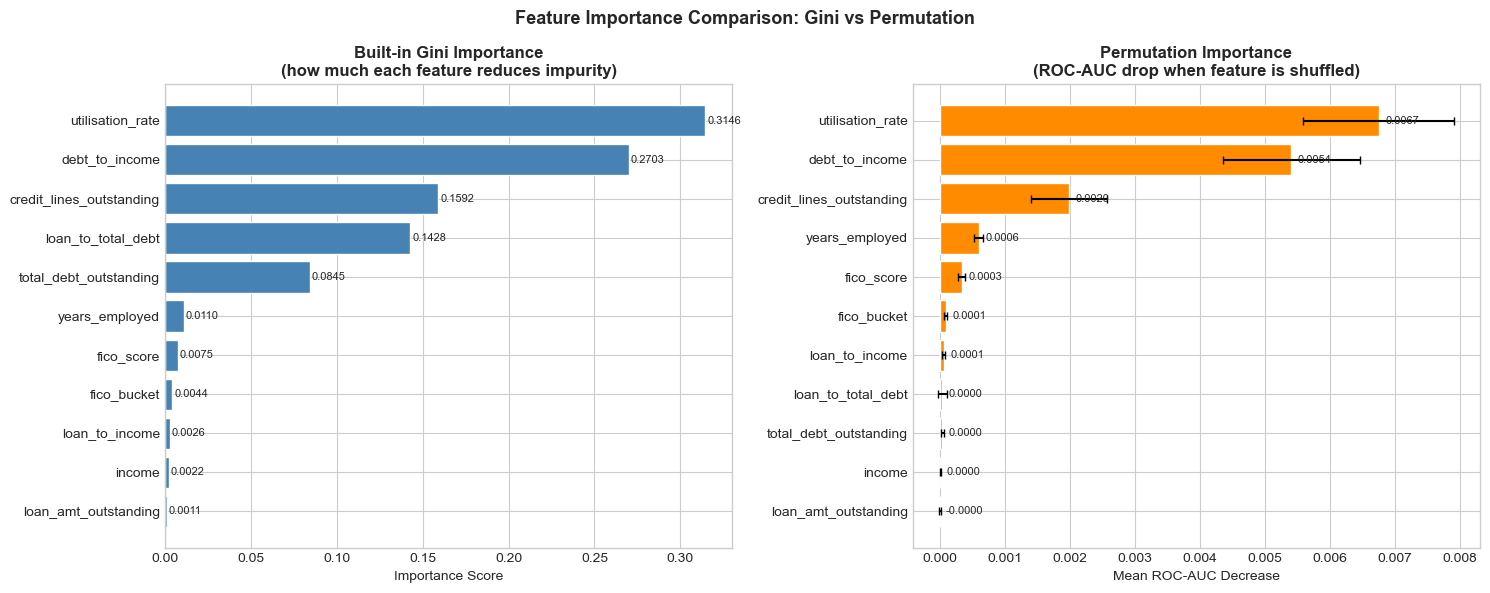

COMPARATIVE RANKING: Gini vs Permutation Importance
                 Feature  Gini_Rank  Gini_Score  Perm_Rank  Perm_Score  Rank_Difference
        utilisation_rate          1    0.314574          1    0.006750                0
          debt_to_income          2    0.270267          2    0.005404                0
credit_lines_outstanding          3    0.159157          3    0.001990                0
      loan_to_total_debt          4    0.142827          8    0.000043                4
  total_debt_outstanding          5    0.084465          9    0.000038                4
          years_employed          6    0.010954          4    0.000597                2
              fico_score          7    0.007505          5    0.000336                2
             fico_bucket          8    0.004361          6    0.000092                2
          loan_to_income          9    0.002638          7    0.000059                2
                  income         10    0.002186         10    0.0000

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fi_sorted = fi_df.sort_values('Gini_Importance')
axes[0].barh(fi_sorted['Feature'], fi_sorted['Gini_Importance'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Built-in Gini Importance\n(how much each feature reduces impurity)',
                  fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, val in enumerate(fi_sorted['Gini_Importance']):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

perm_sorted = perm_df.sort_values('Permutation_Mean')
axes[1].barh(perm_sorted['Feature'], perm_sorted['Permutation_Mean'],
             xerr=perm_sorted['Permutation_Std'],
             color='darkorange', edgecolor='white', capsize=3)
axes[1].set_title('Permutation Importance\n(ROC-AUC drop when feature is shuffled)',
                  fontweight='bold')
axes[1].set_xlabel('Mean ROC-AUC Decrease')
for i, val in enumerate(perm_sorted['Permutation_Mean']):
    axes[1].text(val + 0.0001, i, f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Feature Importance Comparison: Gini vs Permutation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
fi_rank            = fi_df[['Feature']].copy()
fi_rank['Gini_Rank']   = range(1, len(fi_rank) + 1)
fi_rank['Gini_Score']  = fi_df['Gini_Importance'].values

perm_rank              = perm_df[['Feature']].copy()
perm_rank['Perm_Rank'] = range(1, len(perm_rank) + 1)
perm_rank['Perm_Score']= perm_df['Permutation_Mean'].values

comparison = fi_rank.merge(perm_rank, on='Feature')
comparison['Rank_Difference'] = (comparison['Gini_Rank'] - comparison['Perm_Rank']).abs()
comparison = comparison.sort_values('Gini_Rank')

print("COMPARATIVE RANKING: Gini vs Permutation Importance")
print(comparison.to_string(index=False))

In [35]:
def predict_pd_and_el(loan_properties: dict, recovery_rate: float = 0.10) -> dict:
    lgd      = 1 - recovery_rate
    raw      = loan_properties
    income   = max(raw.get('income', 0), 0)
    loan_amt = max(raw.get('loan_amt_outstanding', 0), 0)
    total_d  = max(raw.get('total_debt_outstanding', 0), 0)
    fico     = raw.get('fico_score', 650)

    features = {
        'credit_lines_outstanding': raw.get('credit_lines_outstanding', 0),
        'loan_amt_outstanding':     loan_amt,
        'total_debt_outstanding':   total_d,
        'income':                   income,
        'years_employed':           raw.get('years_employed', 0),
        'fico_score':               fico,
        'debt_to_income':           total_d  / (income + 1),
        'loan_to_income':           loan_amt / (income + 1),
        'loan_to_total_debt':       loan_amt / (total_d + 1),
        'utilisation_rate':         total_d  / (income * 10 + 1),
        'fico_bucket':              float(pd.cut([fico], bins=[300,580,670,740,800,850],
                                                  labels=[0,1,2,3,4])[0]),
    }

    X_input = pd.DataFrame([features])[ALL_FEATURES]
    pd_prob = float(rf.predict_proba(X_input)[0, 1])
    el      = pd_prob * lgd * loan_amt

    if pd_prob < 0.05:    risk_tier = 'Low Risk'
    elif pd_prob < 0.15:  risk_tier = 'Medium Risk'
    elif pd_prob < 0.30:  risk_tier = 'High Risk'
    else:                 risk_tier = 'Very High Risk'

    return {
        'customer_id':   raw.get('customer_id', 'N/A'),
        'PD':            round(pd_prob, 6),
        'PD_pct':        f"{pd_prob:.2%}",
        'LGD':           lgd,
        'EAD':           round(loan_amt, 2),
        'Expected_Loss': round(el, 2),
        'Risk_Tier':     risk_tier,
    }


PORTFOLIO LOSS SUMMARY
Number of loans:         2,000
Total EAD:              $  8,373,362.00
Model Expected Loss:    $  1,601,091.94
Actual Realised Loss:   $  1,483,568.07

Expected Loss / EAD:    19.12%
Actual Loss   / EAD:    17.72%


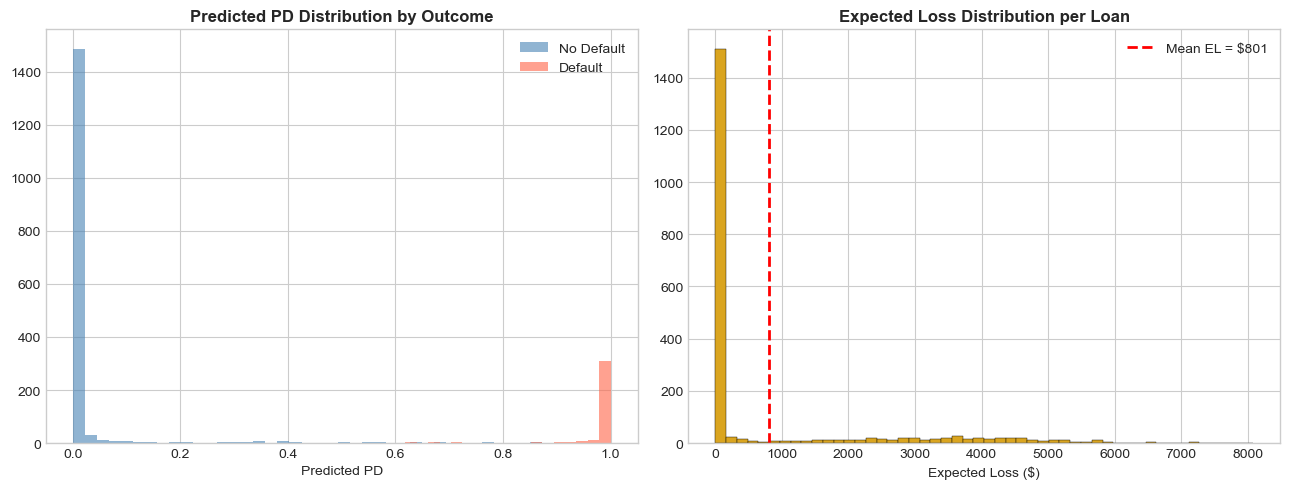

In [36]:
portfolio = X_test.copy()
portfolio['actual_default'] = y_test.values
portfolio['PD']             = rf_proba
portfolio['EAD']            = portfolio['loan_amt_outstanding']
portfolio['Expected_Loss']  = portfolio['PD'] * LGD * portfolio['EAD']
portfolio['Actual_Loss']    = portfolio['actual_default'] * LGD * portfolio['EAD']

print("PORTFOLIO LOSS SUMMARY")
print(f"Number of loans:         {len(portfolio):,}")
print(f"Total EAD:              ${portfolio['EAD'].sum():>14,.2f}")
print(f"Model Expected Loss:    ${portfolio['Expected_Loss'].sum():>14,.2f}")
print(f"Actual Realised Loss:   ${portfolio['Actual_Loss'].sum():>14,.2f}")
print(f"\nExpected Loss / EAD:    {portfolio['Expected_Loss'].sum() / portfolio['EAD'].sum():.2%}")
print(f"Actual Loss   / EAD:    {portfolio['Actual_Loss'].sum()    / portfolio['EAD'].sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(portfolio[portfolio['actual_default']==0]['PD'], bins=40,
             alpha=0.6, color='steelblue', label='No Default')
axes[0].hist(portfolio[portfolio['actual_default']==1]['PD'], bins=40,
             alpha=0.6, color='tomato', label='Default')
axes[0].set_title('Predicted PD Distribution by Outcome', fontweight='bold')
axes[0].set_xlabel('Predicted PD')
axes[0].legend()

axes[1].hist(portfolio['Expected_Loss'], bins=50, color='goldenrod', edgecolor='k', linewidth=0.3)
axes[1].axvline(portfolio['Expected_Loss'].mean(), color='red', lw=2,
                linestyle='--', label=f"Mean EL = ${portfolio['Expected_Loss'].mean():,.0f}")
axes[1].set_title('Expected Loss Distribution per Loan', fontweight='bold')
axes[1].set_xlabel('Expected Loss ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [37]:
def precompute_mse_cost(scores):
    n = len(scores)
    cost = np.zeros((n, n))
    for i in range(n):
        subset = scores[i:i+1]
        for j in range(i, n):
            subset = scores[i:j+1]
            cost[i][j] = np.sum((subset - subset.mean()) ** 2)
    return cost


def precompute_ll_cost(scores, defaults):
    n = len(scores)
    cost = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            n_i = j - i + 1
            k_i = defaults[i:j+1].sum()
            p_i = k_i / n_i if n_i > 0 else 0
            if p_i == 0 or p_i == 1:          
                cost[i][j] = 0
            else:
                ll = k_i * np.log(p_i) + (n_i - k_i) * np.log(1 - p_i)
                cost[i][j] = -ll               
    return cost


def dp_bucketing(cost_matrix, n_buckets):
    n = cost_matrix.shape[0]
    INF = float('inf')
    dp   = np.full((n_buckets + 1, n), INF)
    split = np.full((n_buckets + 1, n), -1, dtype=int)

    for i in range(n):
        dp[1][i] = cost_matrix[0][i]

    for b in range(2, n_buckets + 1):
        for i in range(b - 1, n):
            for m in range(b - 2, i):
                val = dp[b - 1][m] + cost_matrix[m + 1][i]
                if val < dp[b][i]:
                    dp[b][i] = val
                    split[b][i] = m

    boundaries = []
    idx = n - 1
    for b in range(n_buckets, 1, -1):
        boundaries.append(idx)
        idx = split[b][idx]
    boundaries.append(idx)
    boundaries.reverse()
    return boundaries


def boundaries_to_score_thresholds(sorted_scores, boundary_indices):
    thresholds = [sorted_scores[0]]             
    for i in boundary_indices[:-1]:
        thresholds.append(sorted_scores[i])     
    thresholds.append(sorted_scores[-1])        
    return thresholds


def assign_rating(fico, thresholds):
    for i, t in enumerate(thresholds[1:], start=1):
        if fico <= t:
            return i
    return len(thresholds) - 1


In [38]:
N_BUCKETS = 5

fico_data = df[['fico_score', 'default']].sort_values('fico_score').reset_index(drop=True)
sorted_scores   = fico_data['fico_score'].values
sorted_defaults = fico_data['default'].values

print(f"FICO score range : {sorted_scores.min()} – {sorted_scores.max()}")
print(f"Total records    : {len(sorted_scores):,}")
print(f"Overall default rate: {sorted_defaults.mean():.2%}")

print("\nPrecomputing cost matrices")
cost_mse = precompute_mse_cost(sorted_scores.astype(float))
cost_ll  = precompute_ll_cost(sorted_scores, sorted_defaults)

FICO score range : 408 – 850
Total records    : 10,000
Overall default rate: 18.51%

Precomputing cost matrices…


In [40]:
boundaries_mse = dp_bucketing(cost_mse, N_BUCKETS)
boundaries_ll  = dp_bucketing(cost_ll,  N_BUCKETS)

thresholds_mse = boundaries_to_score_thresholds(sorted_scores, boundaries_mse)
thresholds_ll  = boundaries_to_score_thresholds(sorted_scores, boundaries_ll)

print(f"MSE-Optimal Thresholds ({N_BUCKETS} buckets)")
for i in range(N_BUCKETS):
    print(f"  Rating {i+1}: FICO {thresholds_mse[i]:>4} – {thresholds_mse[i+1]}")

print(f"Log-Likelihood-Optimal Thresholds ({N_BUCKETS} buckets)")
for i in range(N_BUCKETS):
    print(f"  Rating {i+1}: FICO {thresholds_ll[i]:>4} – {thresholds_ll[i+1]}")

df['fico_rating_mse'] = df['fico_score'].apply(lambda x: assign_rating(x, thresholds_mse))
df['fico_rating_ll']  = df['fico_score'].apply(lambda x: assign_rating(x, thresholds_ll))

def bucket_summary(df, rating_col, thresholds):
    rows = []
    for i in range(1, N_BUCKETS + 1):
        subset = df[df[rating_col] == i]
        rows.append({
            'Rating': i,
            'FICO Range': f"{thresholds[i-1]} – {thresholds[i]}",
            'Count': len(subset),
            'Default Rate': f"{subset['default'].mean():.2%}",
            'Avg FICO': f"{subset['fico_score'].mean():.1f}"
        })
    return pd.DataFrame(rows)

print("MSE Bucket Summary")
display(bucket_summary(df, 'fico_rating_mse', thresholds_mse))

print("\nLog-Likelihood Bucket Summary")
display(bucket_summary(df, 'fico_rating_ll', thresholds_ll))

MSE-Optimal Thresholds (5 buckets)
  Rating 1: FICO  408 – 552
  Rating 2: FICO  552 – 607
  Rating 3: FICO  607 – 654
  Rating 4: FICO  654 – 706
  Rating 5: FICO  706 – 850
Log-Likelihood-Optimal Thresholds (5 buckets)
  Rating 1: FICO  408 – 521
  Rating 2: FICO  521 – 580
  Rating 3: FICO  580 – 640
  Rating 4: FICO  640 – 696
  Rating 5: FICO  696 – 850
MSE Bucket Summary


,Rating,FICO Range,Count,Default Rate,Avg FICO
0,1,408 – 552,797,53.70%,522.1
1,2,552 – 607,2240,28.35%,583.4
2,3,607 – 654,3036,16.07%,631.5
3,4,654 – 706,2634,9.19%,677.8
4,5,706 – 850,1293,4.49%,734.9



Log-Likelihood Bucket Summary


,Rating,FICO Range,Count,Default Rate,Avg FICO
0,1,408 – 521,316,65.19%,496.4
1,2,521 – 580,1392,38.00%,557.6
2,3,580 – 640,3438,20.45%,612.8
3,4,640 – 696,3197,10.51%,666.4
4,5,696 – 850,1657,4.65%,727.5
